# Module 4 - Class 2: Logistic Regression for Churn Classification

**Dataset:** Telco Customer Churn  
**Objective:** Train a logistic regression classifier and understand classification metrics.

### What you will learn
- Logistic regression training and prediction
- Confusion matrix
- Precision, Recall, F1, ROC-AUC
- ROC curve
- Coefficient interpretation (odds ratios)
- Decision threshold tuning

---

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score, roc_curve
)
import warnings
warnings.filterwarnings('ignore')

print("Setup complete.")

Setup complete.


## 1. Load and Preprocess Data

In [2]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

# Fix TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Standardize service columns
replace_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in replace_cols:
    df[col] = df[col].replace('No internet service', 'No')
df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')

# Target
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

# Features and target
X = df.drop(['customerID', 'Churn'], axis=1)
y = df['Churn']

numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include='object').columns.tolist()

print(f"Shape: {X.shape}")
print(f"Churn rate: {y.mean():.2%}")

Shape: (7043, 19)
Churn rate: 26.54%


In [3]:
# Build preprocessing pipeline
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, cat_cols)
])

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (5634, 19), Test: (1409, 19)


## 2. Train Logistic Regression

In [4]:
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Accuracy: 0.8055


## 3. Confusion Matrix

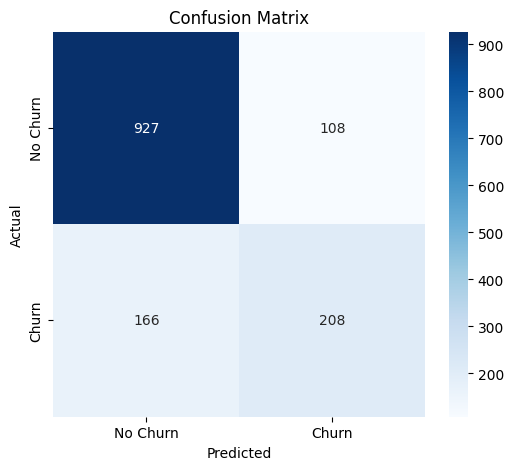

True Negatives:  927
False Positives: 108
False Negatives: 166
True Positives:  208


In [5]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")

## 4. Classification Metrics

In [6]:
print("Full Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

Full Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.90      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

ROC-AUC: 0.8421


In [7]:
# Individual metrics
metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_proba)
}

for name, val in metrics.items():
    print(f"{name:>10}: {val:.4f}")

  Accuracy: 0.8055
 Precision: 0.6582
    Recall: 0.5561
        F1: 0.6029
   ROC-AUC: 0.8421


## 5. ROC Curve

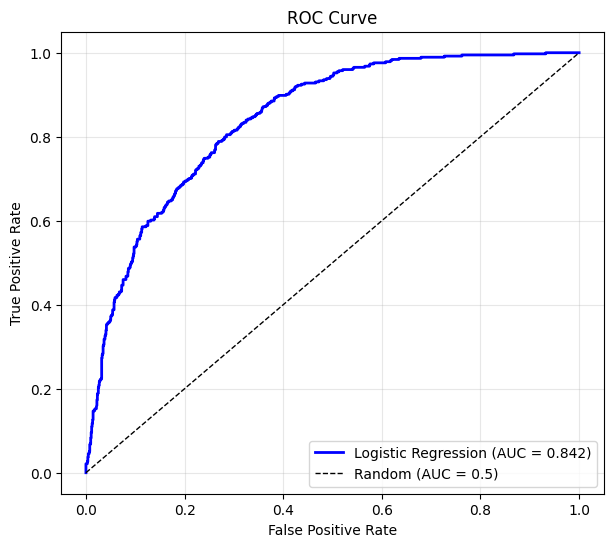

In [8]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_val = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'Logistic Regression (AUC = {auc_val:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6. Coefficient Interpretation (Odds Ratios)

In logistic regression, exp(coefficient) gives the odds ratio: how much the odds of churn multiply when the feature increases by 1 unit.

In [9]:
# Get feature names after encoding
ohe = pipe.named_steps['preprocessor'].named_transformers_['cat'].named_steps['encoder']
cat_feature_names = ohe.get_feature_names_out(cat_cols).tolist()
all_feature_names = numeric_cols + cat_feature_names

# Coefficients and odds ratios
coefs = pipe.named_steps['classifier'].coef_[0]
coef_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': coefs,
    'Odds Ratio': np.exp(coefs)
}).sort_values('Coefficient', ascending=False)

print("Top 10 features increasing churn:")
print(coef_df.head(10).to_string(index=False))
print()
print("Top 10 features decreasing churn:")
print(coef_df.tail(10).to_string(index=False))

Top 10 features increasing churn:
                       Feature  Coefficient  Odds Ratio
   InternetService_Fiber optic     1.032414    2.807836
                  TotalCharges     0.492870    1.637008
PaymentMethod_Electronic check     0.390624    1.477902
          PaperlessBilling_Yes     0.373868    1.453345
             MultipleLines_Yes     0.333192    1.395416
           StreamingMovies_Yes     0.316507    1.372326
               StreamingTV_Yes     0.314302    1.369303
    PaymentMethod_Mailed check     0.077175    1.080231
                 SeniorCitizen     0.054058    1.055546
                   Partner_Yes     0.021941    1.022183

Top 10 features decreasing churn:
           Feature  Coefficient  Odds Ratio
  OnlineBackup_Yes    -0.127669    0.880145
    Dependents_Yes    -0.228734    0.795540
    MonthlyCharges    -0.276811    0.758198
   TechSupport_Yes    -0.328675    0.719877
  PhoneService_Yes    -0.373776    0.688131
OnlineSecurity_Yes    -0.375468    0.686968
 Contra

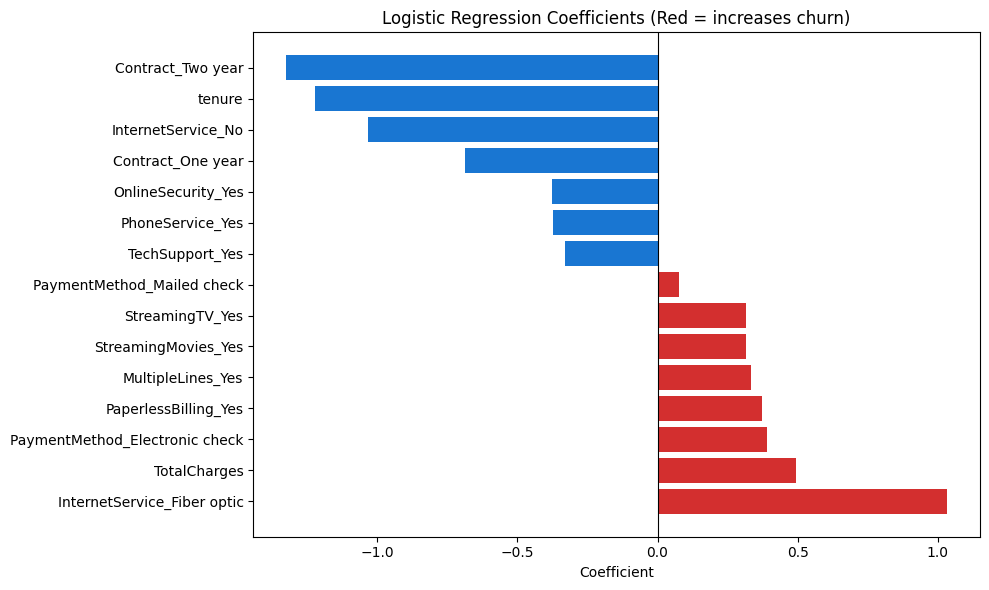

In [10]:
# Visualize top features
top_n = 15
top_features = pd.concat([coef_df.head(top_n // 2 + 1), coef_df.tail(top_n // 2)])

plt.figure(figsize=(10, 6))
colors = ['#d32f2f' if c > 0 else '#1976d2' for c in top_features['Coefficient']]
plt.barh(top_features['Feature'], top_features['Coefficient'], color=colors)
plt.xlabel('Coefficient')
plt.title('Logistic Regression Coefficients (Red = increases churn)')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

## 7. TODO: Threshold Adjustment

By default, logistic regression uses a threshold of 0.5 to classify. Lowering the threshold catches more churners (higher recall) but also more false positives (lower precision).

**Your task:**
1. Classify using thresholds 0.3, 0.4, and 0.5
2. Compute precision, recall, and F1 for each
3. Build a comparison table
4. Write a brief conclusion: which threshold would you choose for a churn prevention campaign and why?

In [11]:
# List of threshold values we want to test
thresholds_to_test = [0.3, 0.4, 0.5]

# Empty list that will store the metrics for each threshold
threshold_results = []

# Loop through every threshold value
for t in thresholds_to_test:

    # Convert probabilities into class predictions (0 or 1)
    # If probability is greater than or equal to the threshold,
    # predict churn (1), otherwise predict no churn (0)
    y_pred_t = (y_proba >= t).astype(int)

    # Calculate Precision:
    # Out of all customers predicted as churn,
    # how many actually churned?
    precision = precision_score(y_test, y_pred_t)

    # Calculate Recall:
    # Out of all customers who actually churned,
    # how many did we successfully identify?
    recall = recall_score(y_test, y_pred_t)

    # Calculate F1 Score:
    # Harmonic mean of Precision and Recall
    f1 = f1_score(y_test, y_pred_t)

    # Store results for this threshold as a dictionary
    threshold_results.append({
        'Threshold': t,
        'Precision': precision,
        'Recall': recall,
        'F1': f1
    })

# Convert the list of dictionaries into a pandas DataFrame
comparison_df = pd.DataFrame(threshold_results)

# Round values to 4 decimal places for cleaner display
comparison_df = comparison_df.round(4)

# Display the comparison table
print(comparison_df)

   Threshold  Precision  Recall      F1
0        0.3     0.5203  0.7540  0.6157
1        0.4     0.5718  0.6711  0.6175
2        0.5     0.6582  0.5561  0.6029


**TODO:** Write your conclusion below.

Which threshold would you choose for a churn prevention campaign and why?

*Your answer here:*

I would choose a threshold of 0.4 for a churn prevention campaign. It provides the best balance between precision and recall and achieves the highest F1-score (0.6175). While a threshold of 0.3 identifies more churners, it also produces many false positives. A threshold of 0.5 is more precise but misses too many customers who are likely to churn. Therefore, 0.4 is the most balanced and practical choice for a customer retention campaign.



---
## Summary

| Concept | Details |
|---------|---------|
| Logistic Regression | Predicts probability of class membership |
| Confusion Matrix | TP, FP, TN, FN breakdown |
| Precision | Of predicted positives, how many are correct |
| Recall | Of actual positives, how many were caught |
| F1 | Harmonic mean of precision and recall |
| ROC-AUC | Area under ROC curve (1.0 = perfect, 0.5 = random) |
| Odds Ratio | exp(coef): multiplicative change in odds per unit increase |
| Threshold | Lower = more recall, less precision |

[Текст ссылки](https://)# Новый раздел

# Homework


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve, classification_report,
    ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')

print("Setup complete.")

Setup complete.


In [13]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

# Convert TotalCharges from text to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill missing values with median
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Encode target variable
# Yes -> 1, No -> 0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Find categorical columns
cat_cols = df.select_dtypes(include='object').columns.drop('customerID')

# One-hot encode categorical features
df_encoded = pd.get_dummies(
    df.drop('customerID', axis=1),
    columns=cat_cols,
    drop_first=True
)

# Create features and target
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create scaler
scaler = StandardScaler()

# Numerical columns to scale
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Fit scaler on training data and transform
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

# Transform test data using same scaler
X_test[num_cols] = scaler.transform(X_test[num_cols])

# Display shapes
print(X_train.shape)
print(X_test.shape)


(5634, 30)
(1409, 30)


In [14]:
# Create logistic regression model
model = LogisticRegression(max_iter=1000)

# Train model
model.fit(X_train, y_train)

# Predict classes
y_pred = model.predict(X_test)

# Predict probabilities
y_proba = model.predict_proba(X_test)[:, 1]

# Display accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8055358410220014


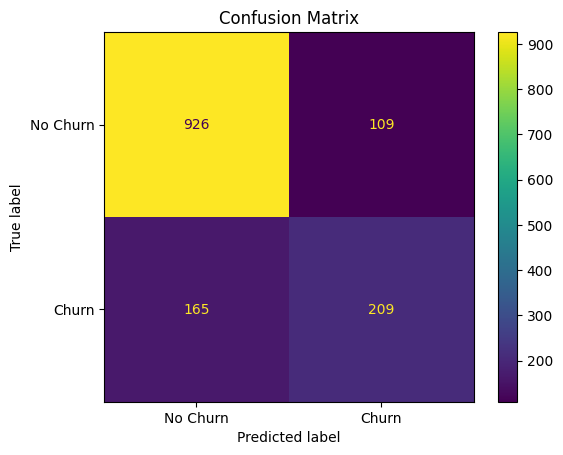

In [15]:
# Display confusion matrix
ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test,
    display_labels=['No Churn', 'Churn']
)

plt.title('Confusion Matrix')
plt.show()

In [16]:
# Print classification metrics
print(
    classification_report(
        y_test,
        y_pred,
        target_names=['No Churn', 'Churn']
    )
)

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



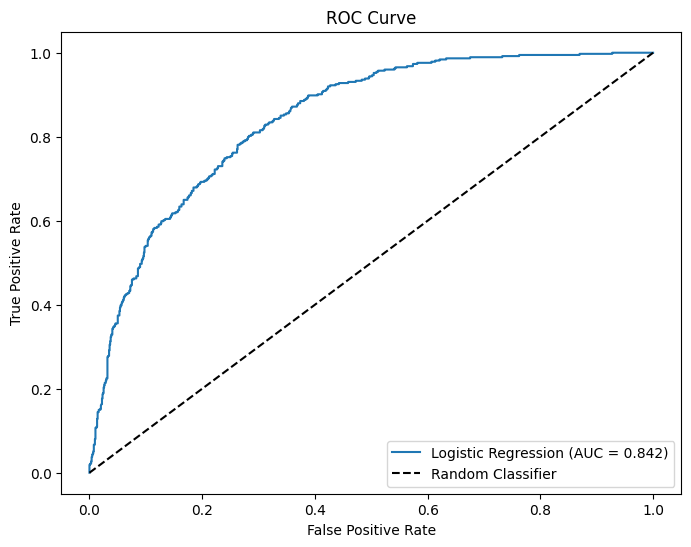

AUC: 0.8420677361853834


In [17]:
# Calculate ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# Calculate AUC
auc = roc_auc_score(y_test, y_proba)

# Plot ROC curve
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f'Logistic Regression (AUC = {auc:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    'k--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.show()

print("AUC:", auc)

In [18]:
# Create coefficient table
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_[0]
})

# Sort coefficients
coef_df = coef_df.sort_values(
    'Coefficient',
    ascending=False
)

# Top 5 features increasing churn
print("Top 5 churn features:")
print(coef_df.head(5))

# Top 5 features decreasing churn
print("\nTop 5 retention features:")
print(coef_df.tail(5))

Top 5 churn features:
                           Feature  Coefficient
10     InternetService_Fiber optic     1.190576
3                     TotalCharges     0.511378
23             StreamingMovies_Yes     0.380384
21                 StreamingTV_Yes     0.378872
28  PaymentMethod_Electronic check     0.377641

Top 5 retention features:
              Feature  Coefficient
2      MonthlyCharges    -0.477810
7    PhoneService_Yes    -0.491306
24  Contract_One year    -0.690863
1              tenure    -1.237578
25  Contract_Two year    -1.337453


In [19]:
# Threshold values to test
thresholds = [0.3, 0.5, 0.7]

# Store results
results = []

for threshold in thresholds:

    # Convert probabilities to predictions
    y_pred_t = (y_proba >= threshold).astype(int)

    # Calculate metrics
    precision = precision_score(y_test, y_pred_t)
    recall = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)

    # Save results
    results.append([
        threshold,
        precision,
        recall,
        f1
    ])

    print(f"\nThreshold: {threshold}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1: {f1:.4f}")

# Create comparison table
comparison_df = pd.DataFrame(
    results,
    columns=['Threshold', 'Precision', 'Recall', 'F1']
)

print("\nComparison Table:")
print(comparison_df)


Threshold: 0.3
Precision: 0.5193
Recall: 0.7540
F1: 0.6150

Threshold: 0.5
Precision: 0.6572
Recall: 0.5588
F1: 0.6040

Threshold: 0.7
Precision: 0.7391
Recall: 0.1818
F1: 0.2918

Comparison Table:
   Threshold  Precision    Recall        F1
0        0.3   0.519337  0.754011  0.615049
1        0.5   0.657233  0.558824  0.604046
2        0.7   0.739130  0.181818  0.291845
